In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [ ]:
pet_images_path = "/content/drive/MyDrive/AI_Projects/Cats_vs_Dogs/data/PetImages"

**Image Transform**

In [ ]:
weights = ResNet18_Weights.DEFAULT
transform = weights.transforms()

**Load Dataset**

In [ ]:
dataset = datasets.ImageFolder(
    root=pet_images_path,
    transform=transform
)

print(f"Number of images: {len(dataset)}")
print(f"Classes: {dataset.classes}")

Number of images: 24998
Classes: ['Cat', 'Dog']


**Display Random Images**

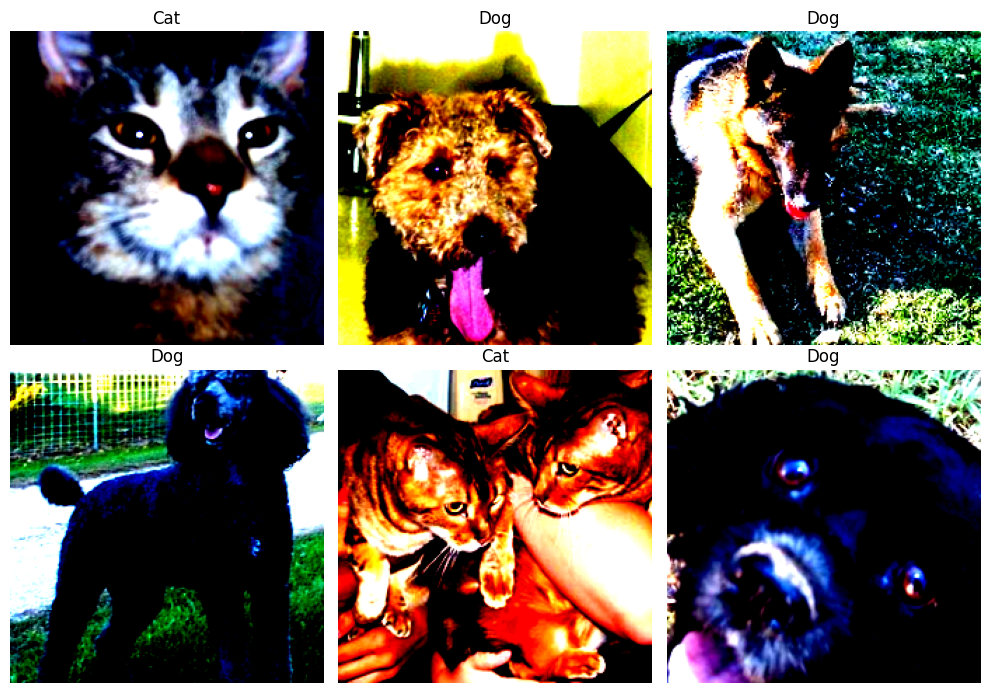

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax in axes.ravel():
    image, label = dataset[random.randint(0, len(dataset)-1)]

    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

**Split dataset**

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train Images: {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")
print(f"Test Images: {len(test_dataset)}")

Train Images: 19998
Validation Images: 2499
Test Images: 2501


**DataLoader**

In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

**ResNet**

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Replace the last layer
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to device
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last layer
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to GPU/CPU
model = model.to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer (only the last layer)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

print(device)

cuda


In [ ]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):

    # Training

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total


    # Validation

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss / len(val_loader):.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

  4%|▍         | 27/625 [01:45<06:15,  1.59it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 625/625 [04:27<00:00,  2.34it/s]



Epoch 1/5
Train Loss: 0.1130
Train Accuracy: 95.80%
Validation Loss: 0.0560
Validation Accuracy: 98.00%


 94%|█████████▎| 585/625 [02:11<00:07,  5.12it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 625/625 [02:21<00:00,  4.42it/s]



Epoch 2/5
Train Loss: 0.0772
Train Accuracy: 96.96%
Validation Loss: 0.0512
Validation Accuracy: 98.16%


  0%|          | 0/625 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 625/625 [02:18<00:00,  4.50it/s]



Epoch 3/5
Train Loss: 0.0714
Train Accuracy: 97.13%
Validation Loss: 0.0549
Validation Accuracy: 97.60%


 45%|████▍     | 279/625 [01:04<01:41,  3.42it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 625/625 [02:21<00:00,  4.42it/s]



Epoch 4/5
Train Loss: 0.0723
Train Accuracy: 97.13%
Validation Loss: 0.0467
Validation Accuracy: 98.24%


 59%|█████▉    | 369/625 [01:22<01:17,  3.30it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 625/625 [02:22<00:00,  4.39it/s]



Epoch 5/5
Train Loss: 0.0707
Train Accuracy: 97.23%
Validation Loss: 0.0808
Validation Accuracy: 96.76%


**Test Set**

In [ ]:
model.eval()

test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.0877
Test Accuracy: 97.00%


**confusion matrix, classification report**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes
))

Confusion Matrix:
[[1257    3]
 [  72 1169]]

Classification Report:
              precision    recall  f1-score   support

         Cat       0.95      1.00      0.97      1260
         Dog       1.00      0.94      0.97      1241

    accuracy                           0.97      2501
   macro avg       0.97      0.97      0.97      2501
weighted avg       0.97      0.97      0.97      2501



**Save Model**

In [ ]:
torch.save(model.state_dict(), "cats_vs_dogs_resnet18.pth")